# Выполнил
Дмитрий Трифонов, 12-25РПм, 1 курс, Программная инженерия

# Практическое занятие 2.1
## Минимизация квадратичной функции, проклятие размерности и случайный поиск

Цель работы:
- изучить явление проклятия размерности;
- исследовать минимизацию квадратичной функции;
- реализовать алгоритм случайного поиска;
- сравнить фиксированную и убывающую длину шага.


## Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Упражнение 2.1 — Проклятие размерности

Рассмотрим гиперкуб [-1,1]^N и равномерное покрытие с шагом h = 0.1.

In [2]:
h = 0.1
Ns = np.array([1, 2, 3, 4, 5, 10])
K = (2 / h) ** Ns

for n, k in zip(Ns, K):
    print(f"N = {n}, K = {k:.2e}")

N = 1, K = 2.00e+01
N = 2, K = 4.00e+02
N = 3, K = 8.00e+03
N = 4, K = 1.60e+05
N = 5, K = 3.20e+06
N = 10, K = 1.02e+13


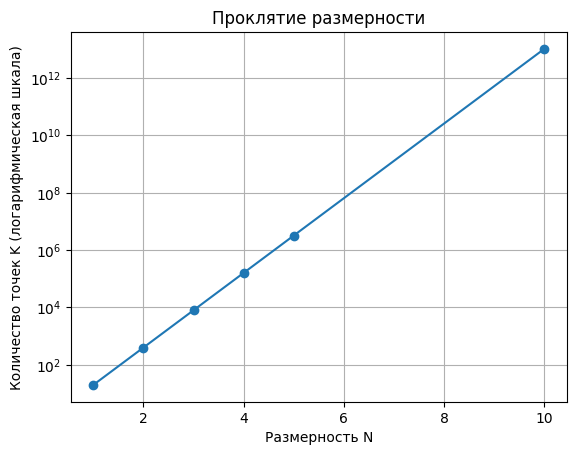

In [3]:
plt.figure()
plt.plot(Ns, K, marker='o')
plt.yscale('log')
plt.xlabel('Размерность N')
plt.ylabel('Количество точек K (логарифмическая шкала)')
plt.title('Проклятие размерности')
plt.grid(True)
plt.show()

## Упражнение 2.2 — Минимизация квадратичной функции

Матрица:
A = [[1, 0], [0, 100]]

In [4]:
A = np.array([[1, 0], [0, 100]])

def g(w):
    w = np.asarray(w)
    return w.T @ A @ w

In [5]:
np.random.seed(0)
points = np.random.uniform(-1, 1, size=(200, 2))
values = np.array([g(p) for p in points])

print("Минимальное значение:", values.min())

Минимальное значение: 0.059510213851970264


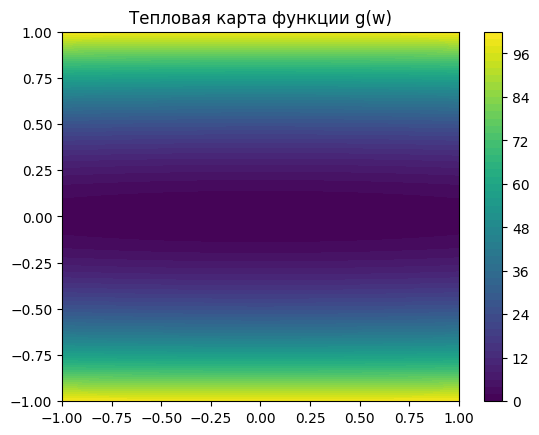

In [6]:
x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + 100*Y**2

plt.figure()
plt.contourf(X, Y, Z, levels=50)
plt.colorbar()
plt.title('Тепловая карта функции g(w)')
plt.show()

## Упражнение 2.3 — Случайный поиск

In [7]:
def random_direction(n):
    v = np.random.randn(n)
    return v / np.linalg.norm(v)

def random_search(g, w0, alpha, iters):
    w = w0.copy()
    history = []
    for k in range(iters):
        history.append(g(w))
        p = random_direction(len(w))
        w_new = w + alpha * p
        if g(w_new) < g(w):
            w = w_new
    return np.array(history)

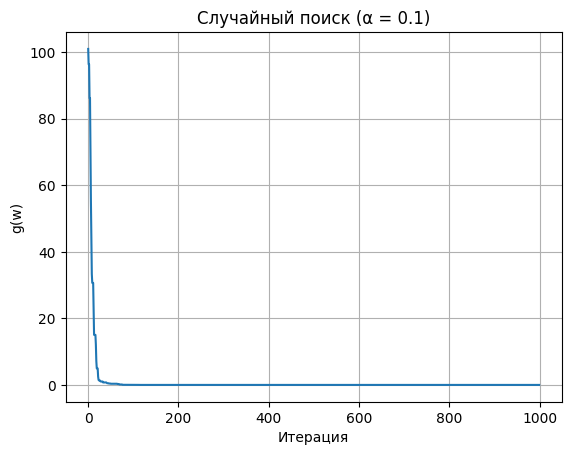

In [8]:
w0 = np.array([-1.0, 1.0])
hist = random_search(g, w0, alpha=0.1, iters=1000)

plt.figure()
plt.plot(hist)
plt.xlabel('Итерация')
plt.ylabel('g(w)')
plt.title('Случайный поиск (α = 0.1)')
plt.grid(True)
plt.show()

## Упражнение 2.4 — Сравнение длины шага

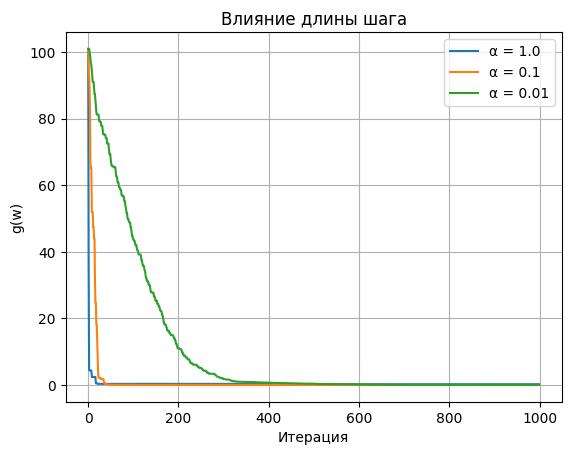

In [9]:
alphas = [1.0, 0.1, 0.01]

plt.figure()
for alpha in alphas:
    hist = random_search(g, w0, alpha, 1000)
    plt.plot(hist, label=f'α = {alpha}')

plt.xlabel('Итерация')
plt.ylabel('g(w)')
plt.legend()
plt.grid(True)
plt.title('Влияние длины шага')
plt.show()

## Упражнение 2.5 — Убывающая длина шага

In [10]:
def random_search_decay(g, w0, alpha0, iters):
    w = w0.copy()
    history = []
    for k in range(iters):
        history.append(g(w))
        alpha = alpha0 / (k + 1)
        p = random_direction(len(w))
        w_new = w + alpha * p
        if g(w_new) < g(w):
            w = w_new
    return np.array(history)

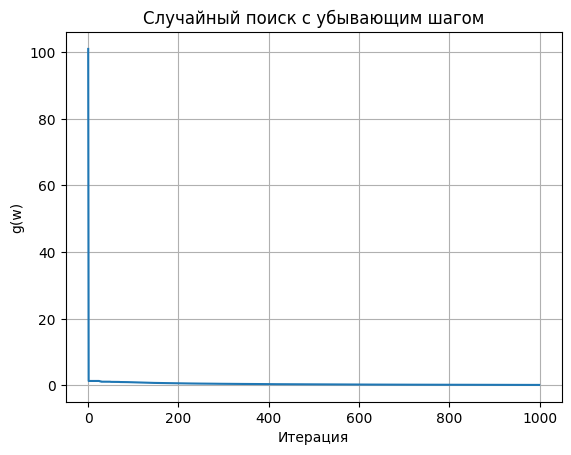

In [11]:
hist_decay = random_search_decay(g, w0, alpha0=1.0, iters=1000)

plt.figure()
plt.plot(hist_decay)
plt.xlabel('Итерация')
plt.ylabel('g(w)')
plt.title('Случайный поиск с убывающим шагом')
plt.grid(True)
plt.show()

## Выводы
- Число точек в гиперкубе растёт экспоненциально с размерностью.
- Случайный поиск эффективен только в малых размерностях.
- Большой шаг приводит к нестабильности.
- Малый шаг замедляет сходимость.
- Убывающий шаг повышает устойчивость, но замедляет процесс.

### 3. Исследовательские задания

### Задание 1. Влияние размерности (N = 5)

Проведём эксперимент случайного поиска для квадратичной функции
$$g(w) = w^T w$$
в пространстве размерности $N = 5$ при разных стратегиях выбора шага.

In [12]:
N = 5
np.random.seed(1)

def quadratic_N(w):
    return np.dot(w, w)

w0_N5 = np.random.uniform(-1, 1, size=N)
iters = 1500

hist_a01 = random_search(quadratic_N, w0_N5, alpha=0.1, iters=iters)
hist_a1 = random_search(quadratic_N, w0_N5, alpha=1.0, iters=iters)
hist_decay = random_search_decay(quadratic_N, w0_N5, alpha0=1.0, iters=iters)

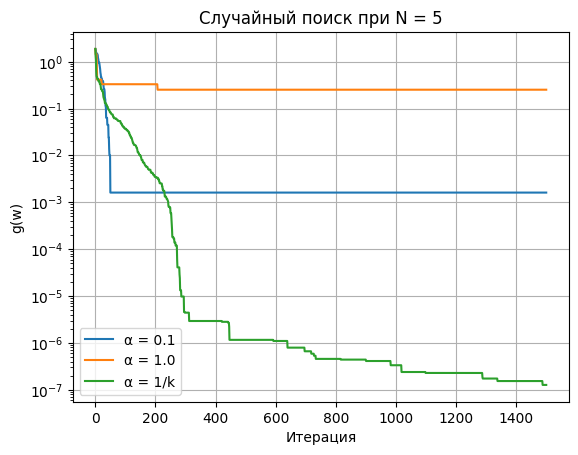

In [13]:
plt.figure()
plt.plot(hist_a01, label='α = 0.1')
plt.plot(hist_a1, label='α = 1.0')
plt.plot(hist_decay, label='α = 1/k')
plt.yscale('log')
plt.xlabel('Итерация')
plt.ylabel('g(w)')
plt.title('Случайный поиск при N = 5')
plt.legend()
plt.grid(True)
plt.show()

#### Выводы по заданию 1
- При $N = 5$ сходимость существенно замедляется по сравнению с двумерным случаем.
- Шаг $\alpha = 1.0$ приводит к высокой вариативности и нестабильности.
- Шаг $\alpha = 0.1$ более устойчив, но сходится медленно.
- Убывающий шаг $\alpha_k = 1/k$ обеспечивает наибольшую стабильность,
  но скорость уменьшения функции самая низкая.
- Проклятие размерности проявляется в снижении эффективности случайного поиска.

### Задание 2. Влияние кривизны функции

Рассмотрим квадратичную функцию с матрицей:
$$
A = \begin{pmatrix} 10 & 0 \\ 0 & 1 \end{pmatrix}
$$
и исследуем влияние кривизны на поведение алгоритма.

In [14]:
A2 = np.array([[10, 0], [0, 1]])

def g_curvature(w):
    return w.T @ A2 @ w

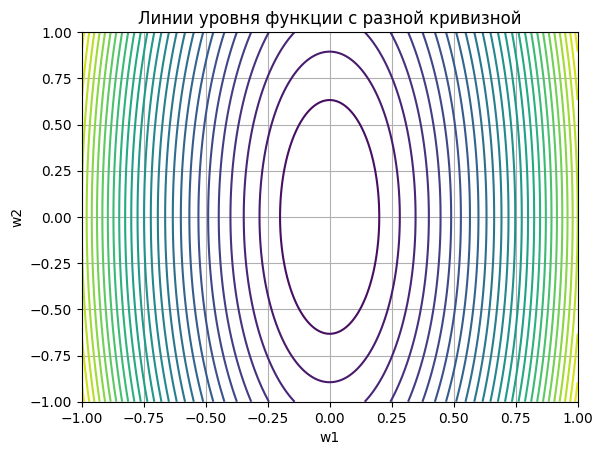

In [15]:
x = np.linspace(-1, 1, 300)
y = np.linspace(-1, 1, 300)
X, Y = np.meshgrid(x, y)
Z = 10*X**2 + Y**2

plt.figure()
plt.contour(X, Y, Z, levels=30)
plt.xlabel('w1')
plt.ylabel('w2')
plt.title('Линии уровня функции с разной кривизной')
plt.grid(True)
plt.show()

In [16]:
w0 = np.array([-1.0, 1.0])

hist_c01 = random_search(g_curvature, w0, alpha=0.1, iters=1200)
hist_c1 = random_search(g_curvature, w0, alpha=1.0, iters=1200)

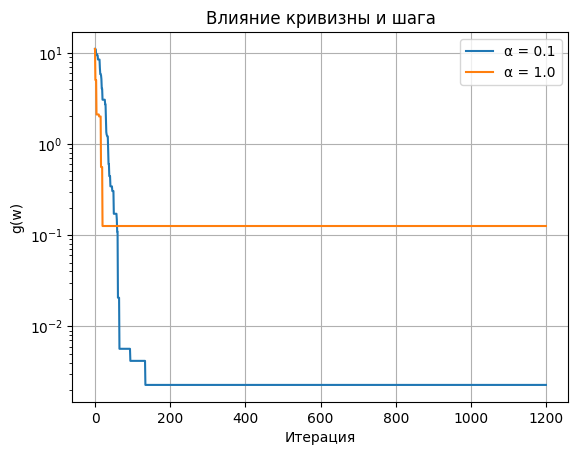

In [17]:
plt.figure()
plt.plot(hist_c01, label='α = 0.1')
plt.plot(hist_c1, label='α = 1.0')
plt.yscale('log')
plt.xlabel('Итерация')
plt.ylabel('g(w)')
plt.title('Влияние кривизны и шага')
plt.legend()
plt.grid(True)
plt.show()

#### Выводы по заданию 2
- Увеличение кривизны приводит к вытянутым линиям уровня.
- Алгоритм становится более чувствительным к выбору длины шага.
- Большой шаг вызывает частые неудачные попытки улучшения.
- Малый шаг обеспечивает устойчивость, но снижает скорость сходимости.

## 4. Контрольные вопросы

**Вопрос 1. Почему число точек в гиперкубе растёт экспоненциально с размерностью?**

При равномерном покрытии гиперкуба [-1,1]^N с шагом h по каждой координате
число точек равно:
$$K = (2/h)^N.$$
При увеличении размерности N каждая новая координата умножает количество точек,
что приводит к экспоненциальному росту и делает перебор практически невозможным.

**Вопрос 2. Как влияет длина шага α на поведение случайного поиска?**

- Большая длина шага приводит к скачкам и нестабильности.
- Малая длина шага делает алгоритм устойчивым, но замедляет сходимость.
- Убывающий шаг сочетает устойчивость и точность, но требует большего числа итераций.

## 5. Общие выводы по практическому занятию

В ходе практической работы:
- продемонстрировано проклятие размерности;
- реализован алгоритм случайного поиска;
- исследовано влияние размерности и кривизны функции;
- показана роль длины шага в устойчивости и скорости сходимости.

Даже простые методы оптимизации становятся неэффективными
при росте размерности, что подчёркивает необходимость более
сложных алгоритмов в задачах машинного обучения.